In [ ]:
### THIS CELL SETS UP THE GOOGLE COLAB ENVIRONMENT.
### IF RUNNING THIS NOTEBOOK LOCALLY, IT MAY BE SAFELY DELETED.

try:
    import google.colab
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False
except Exception as e:
    raise Exception("Could not figure out if running in a colab notebook\n") from e

if RUNNING_IN_COLAB:
    !pip install dataprob

## Hamiltonian Monte Carlo

This notebook demonstrates the `hmc` fitter — a self-contained leapfrog HMC sampler
(pure numpy, no autodiff framework required). HMC uses gradient information to propose
efficient moves through parameter space, dramatically reducing the number of samples
needed compared to random-walk MCMC methods.

If the model object exposes a `jacobian_normalized(params)` method (as produced by
`linkage.GlobalModel`), HMC uses it analytically. Otherwise it falls back to
forward finite differences with a warning.

**When to use:** Parameters are strongly correlated and you have an analytical Jacobian
available. HMC also supports checkpoint/resume for long runs.

### Define model

We use a linear model $y = mx + b$. The same model and data are used across all fitter
notebooks so the outputs can be directly compared.

In [1]:
%matplotlib inline
import dataprob
import numpy as np

def linear_model(m=1, b=1, x=None):
    return m*x + b

### Generate noisy data

30 observations with m = 3, b = 1, and Gaussian noise (σ = 0.5).

In [2]:
true_params = {"m": 3.0, "b": 1.0}

x = np.linspace(0, 10, 30)
y_std = 0.5
y_obs = linear_model(x=x, **true_params) + np.random.normal(0, y_std, size=x.shape)

### Configure priors and guesses

Bounds define a uniform prior between them; proposals outside bounds are reflected back
toward the interior via a repelling gradient. Setting a good initial guess is important —
HMC starts from the guess and adapts step size during burn-in.

In [3]:
f = dataprob.setup(linear_model,
                   method="hmc",
                   non_fit_kwargs={"x": x})

f.param_df.loc["m", "lower_bound"] = -10.0
f.param_df.loc["m", "upper_bound"] =  10.0
f.param_df.loc["b", "lower_bound"] = -10.0
f.param_df.loc["b", "upper_bound"] =  10.0

f.param_df.loc["m", "guess"] = 1.0
f.param_df.loc["b", "guess"] = 0.0

f.param_df

,name,guess,fixed,lower_bound,upper_bound,prior_mean,prior_std
name,,,,,,,
m,m,1.0,False,-10.0,10.0,NaN,NaN
b,b,0.0,False,-10.0,10.0,NaN,NaN


### Run the sampler

`burn_in` samples are discarded; dual averaging tunes `step_size` during this phase to
hit `target_accept`. `n_steps` (leapfrog steps per proposal) controls trajectory length.
Set `output_dir` and `checkpoint_steps` to save progress for long runs.

At startup HMC prints diagnostics — a `log_accept` near zero indicates the initial step
size is appropriate. Acceptance rates during sampling should stay near `target_accept`.

In [4]:
f.fit(y_obs=y_obs,
      y_std=y_std,
      n_samples=2000,
      burn_in=400,
      step_size=0.1,
      n_steps=20,
      target_accept=0.65,
      report_steps=200,
      random_seed=None,
      output_dir=None,
      checkpoint_steps=0,
      resume_from=None,
      hessian_reg=1e-4)

  [diagnostic] gradient norm at x0:  8821.48
  [diagnostic] gradient per param:   m=8724, b=1305
  [diagnostic] test proposal:  H_current=9376.7  H_prop=1e+30  delta_H=1e+30  log_accept=-1e+30
HMCFitter: drawing 2000 samples total (2000 remaining) (step_size=0.1, n_steps=20, gradient=finite-difference, mass=identity, target_accept=0.65 [dual-averaging])


C:\Users\willi\dataprob\src\dataprob\fitters\hmc.py:296: UserWarning: HMCFitter: model does not expose 'jacobian_normalized'. Falling back to forward finite-difference gradient.  This is slower and less accurate than the symbolic Jacobian.
  warnings.warn(


  [burn-in: 400 steps, dual averaging -> target_accept=0.65]
    burn-in 200/400 ( 50.0%)  step_size=0.013757
    burn-in 400/400 (100.0%)  step_size=0.01245
  [burn-in done]  acceptance: 0.65  adapted step_size: 0.0126519  elapsed: 0.6s
  [sampling: 2000 steps (0 -> 2000 total)]
     200/2000 samples ( 10.0%)  acceptance: 0.52  elapsed: 0.9s
     400/2000 samples ( 20.0%)  acceptance: 0.56  elapsed: 1.2s
     600/2000 samples ( 30.0%)  acceptance: 0.56  elapsed: 1.5s
     800/2000 samples ( 40.0%)  acceptance: 0.60  elapsed: 1.8s
    1000/2000 samples ( 50.0%)  acceptance: 0.61  elapsed: 2.1s
    1200/2000 samples ( 60.0%)  acceptance: 0.60  elapsed: 2.4s
    1400/2000 samples ( 70.0%)  acceptance: 0.61  elapsed: 2.7s
    1600/2000 samples ( 80.0%)  acceptance: 0.60  elapsed: 3.0s
    1800/2000 samples ( 90.0%)  acceptance: 0.61  elapsed: 3.3s
    2000/2000 samples (100.0%)  acceptance: 0.61  elapsed: 3.6s
HMCFitter: done.  1600 post-burn-in samples  |  acceptance rate: 0.61  |  3.6 s

### Examine fit results

`f.fit_df["estimate"]` is the mode of the posterior marginal (KDE maximum). `f.samples`
has shape `(n_samples - burn_in, n_params)`. `f._acceptance_rate` reports the overall
Metropolis acceptance rate; `f._step_size` is the final adapted step size.

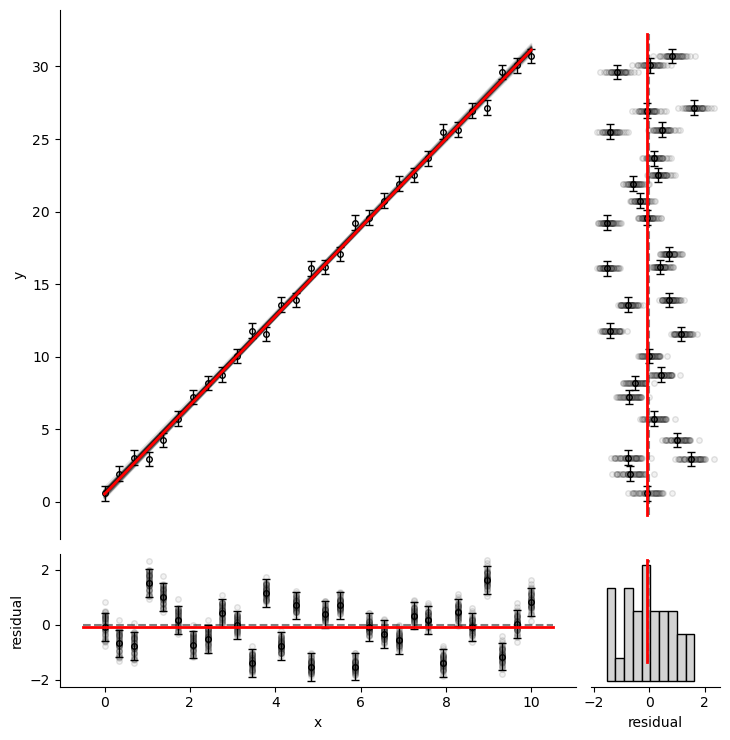

In [5]:
fig = dataprob.plot_summary(f, x_axis=x, x_label="x", y_label="y")

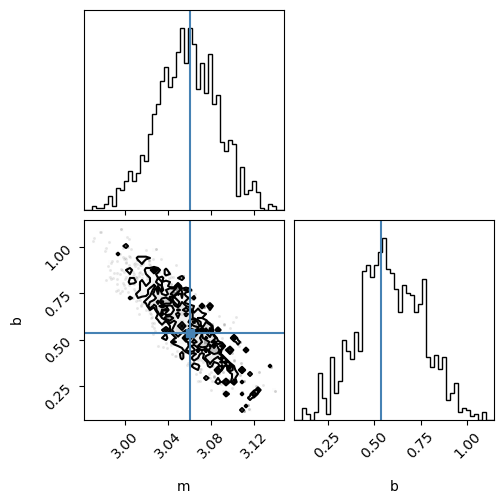

In [6]:
fig = dataprob.plot_corner(f)

In [7]:
f.fit_df

,name,estimate,std,low_95,high_95,guess,fixed,lower_bound,upper_bound,prior_mean,prior_std
name,,,,,,,,,,,
m,m,3.060406,0.028518,3.000427,3.114599,1.0,False,-10.0,10.0,NaN,NaN
b,b,0.538530,0.175610,0.224310,0.930906,0.0,False,-10.0,10.0,NaN,NaN


In [8]:
# HMC-specific diagnostics
print(f"Acceptance rate: {f._acceptance_rate:.3f}  (target: {0.65})")
print(f"Final step size: {f._step_size:.4f}")
print(f"Posterior samples: {f.samples.shape[0]}")

Acceptance rate: 0.613  (target: 0.65)
Final step size: 0.0127
Posterior samples: 1600


### Assess fit quality

For HMC, the key diagnostic is the acceptance rate — it should be near `target_accept`
(0.65 here). Rates below 0.1 suggest the step size is too large; rates above 0.95 suggest
it is too small. Adjust `step_size` or `n_steps` if needed.

In [9]:
f.fit_quality

,description,is_good,value,message
name,,,,
success,fit success status,True,True,
num_obs,number of observations,True,30,
num_param,number of fit parameters,True,2,There are 28 more observations than fit parame...
lnL,log likelihood,True,-18.040146,
chi2,chi^2 goodness-of-fit,True,0.709837,A p-value of 7.098e-01 for the a goodness-of-f...
reduced_chi2,reduced chi^2,True,0.834549,A reduced chi^2 value of 0.835 is consistent w...
mean0_resid,t-test for residual mean != 0,True,0.659023,A p-value of 6.590e-01 for the one-sample t-te...
durbin-watson,Durbin-Watson test for correlated residuals,True,2.597582,A Durbin-Watson test-statistic of 2.598 is con...
ljung-box,Ljung-Box test for correlated residuals,True,0.423845,A p-value of 4.238e-01 for the Ljung-Box test ...
